## Required imports

In [1]:
import matplotlib.pyplot as plt # for plotting
import numpy as np              # numpy 
import qse                      # import the qse
import qse.calc                 # import calculators
import pulser                   # we just need this for R_interatomic
#from qse.utils import squarelattice, triangularlattice, hexagonlattice, kagomelattice

#### 2D square lattice

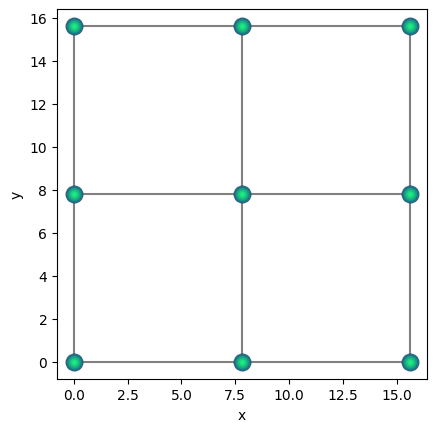

In [3]:
# Parameters in rad/µs and ns

Omega_max = 2.0 * 2 * np.pi
U = Omega_max / 2.0
delta_0 = -6 * U
delta_f = 2 * U
t_rise = 252
t_fall = 500
t_sweep = (delta_f - delta_0) / (2 * np.pi * 10) * 1000

# We extract the reference blockade radius from pulser here
R_interatomic = qse.calc.blockade_radius(U)

L = 3     # lattice size

# Now we generate the qbits object that represents 1D lattice with r0 as lattice spaceing

r0 = 0.8 * R_interatomic
# keeping r0 a bit below blockade radius keeps the nearest neighbours antiferromagnetic

q2d = qse.lattices.square(r0, L, L)

# we can also use qse.utils.triangularlattice, etc. 
# check the qse.utils module.

q2d.draw(radius=R_interatomic)

#### Hamiltonian creation for 2D lattice

In [4]:
amplitude_afm = pulser.CompositeWaveform(
    pulser.waveforms.RampWaveform(t_rise, 0.0, Omega_max),
    pulser.waveforms.ConstantWaveform(t_sweep,Omega_max),
    pulser.waveforms.RampWaveform(t_fall, Omega_max, 0.0)
    )
# up ramp, constant, downramp waveform

detuning_afm = pulser.CompositeWaveform(
    pulser.waveforms.ConstantWaveform(t_rise,delta_0),
    pulser.waveforms.RampWaveform(t_sweep, delta_0, delta_f),
    pulser.waveforms.ConstantWaveform(t_fall,delta_f)
    )
# corresponding waveform for detuning


In [5]:
amplitude_afm.samples

array([0.        , 0.05006522, 0.10013044, ..., 0.05036621, 0.02518311,
       0.        ], shape=(1552,))

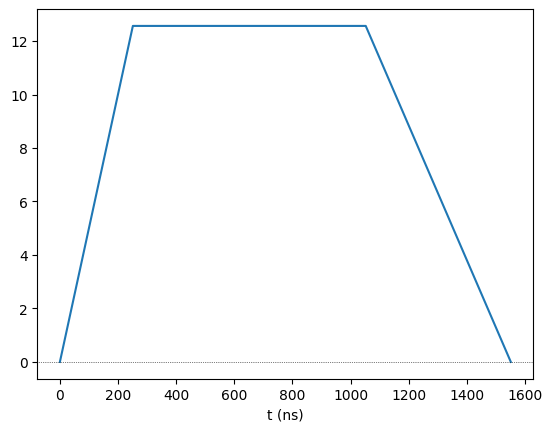

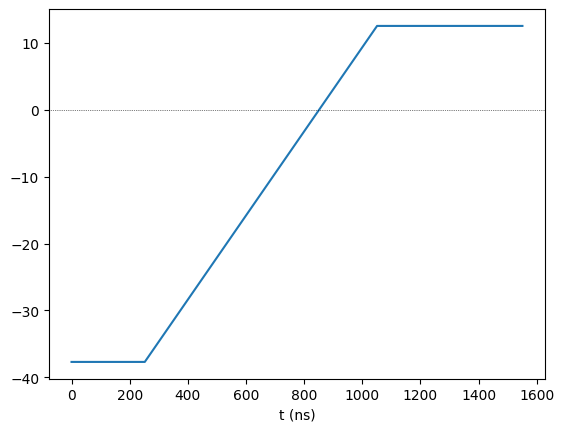

In [6]:
amplitude_afm.draw()
detuning_afm.draw()

#### Setting up the calculator

In [7]:
pcalc =  qse.calc.Pulser(
    qbits = q2d,
    amplitude = amplitude_afm,
    detuning = detuning_afm)

#### Running the job

In [9]:
pcalc.build_sequence()
pcalc.calculate()
results = pcalc.results

10.1%. Run time:   0.00s. Est. time left: 00:00:00:00
20.0%. Run time:   0.01s. Est. time left: 00:00:00:00
30.0%. Run time:   0.02s. Est. time left: 00:00:00:00
40.0%. Run time:   0.02s. Est. time left: 00:00:00:00
50.0%. Run time:   0.03s. Est. time left: 00:00:00:00
60.1%. Run time:   0.03s. Est. time left: 00:00:00:00
70.0%. Run time:   0.04s. Est. time left: 00:00:00:00
80.0%. Run time:   0.04s. Est. time left: 00:00:00:00
90.0%. Run time:   0.05s. Est. time left: 00:00:00:00
100.0%. Run time:   0.06s. Est. time left: 00:00:00:00
Total run time:   0.06s
time in compute and simulation = 0.18506717681884766 s.


#### Sampling the result

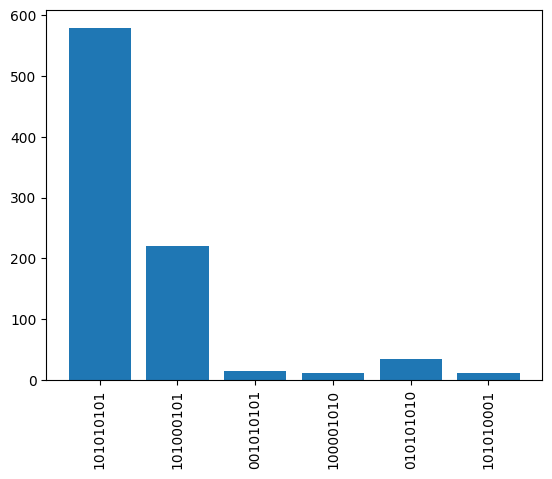

In [10]:
count = results.sample_final_state()

most_freq = {k: v for k, v in count.items() if v > 10}
plt.bar(list(most_freq.keys()), list(most_freq.values()))
plt.xticks(rotation="vertical")
plt.show()


In [12]:
pcalc.spins.reshape(L, L, 3)

array([[[-0.12825035, -0.19415827, -0.703339  ],
        [-0.0274068 , -0.02817537,  0.80799606],
        [-0.12825035, -0.19415827, -0.703339  ]],

       [[-0.0274068 , -0.02817537,  0.80799606],
        [-0.67577314, -0.24103194, -0.231647  ],
        [-0.0274068 , -0.02817537,  0.80799606]],

       [[-0.12825035, -0.19415827, -0.703339  ],
        [-0.0274068 , -0.02817537,  0.80799606],
        [-0.12825035, -0.19415827, -0.703339  ]]])

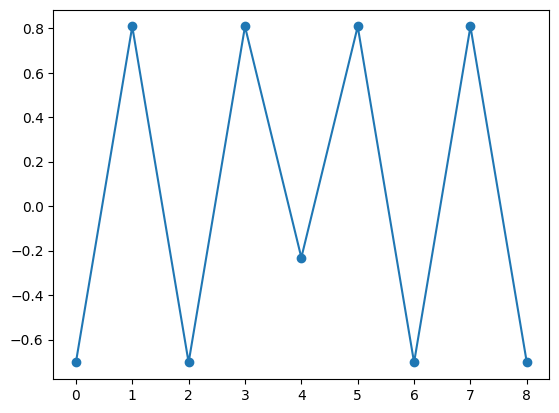

In [14]:
plt.plot(pcalc.spins.dot([0, 0, 1]), 'o-') # overlap with z-axis